### Environment Setup & Data Ingestion

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sentence_transformers import SentenceTransformer

sns.set_theme(style="white", palette="muted")
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["font.size"] = 11

DATA_PATH = os.path.join("..", "dataset", "cleaned_customer_support_tickets.csv")
MODEL_DIR = os.path.join("..", "model_output")
os.makedirs(MODEL_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH).dropna(subset=["cleaned_text", "Target_Department"]).reset_index(drop=True)
print(f"Loaded {len(df)} denoised tickets.")
display(df["Target_Department"].value_counts())

/Users/aryanmishra/Documents/ai_app_gisma_project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 2182 denoised tickets.


Target_Department
Technical Support                    1322
Account Access & Security             541
Finance & Billing                     216
Marketing & Sales                      78
Customer Retention & Cancellation      25
Name: count, dtype: int64

---

### Train / Test Split

In [2]:
X = df["cleaned_text"]
y = df["Target_Department"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train split: {len(X_train)} | Test split: {len(X_test)}")

Train split: 1745 | Test split: 437


---

### Dense SBERT Representation

In [3]:
embedder = SentenceTransformer("all-MiniLM-L6-v2")

print("Encoding train set into 384-dimensional dense vectors...")
X_train_vec = embedder.encode(X_train.tolist(), batch_size=64, show_progress_bar=True, normalize_embeddings=True)

print("Encoding test set...")
X_test_vec = embedder.encode(X_test.tolist(), batch_size=64, show_progress_bar=True, normalize_embeddings=True)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10657.00it/s]


Encoding train set into 384-dimensional dense vectors...


Batches: 100%|██████████| 28/28 [00:01<00:00, 15.76it/s]


Encoding test set...


Batches: 100%|██████████| 7/7 [00:00<00:00, 21.24it/s]


---

### Supervised Model Training

In [4]:
clf = LogisticRegression(
    C=2.0,
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

clf.fit(X_train_vec, y_train)
y_pred = clf.predict(X_test_vec)
acc = accuracy_score(y_test, y_pred)

print("=" * 60)
print(f"DENOISED SBERT SUPERVISED ACCURACY: {acc * 100:.2f}%")
print("=" * 60)

DENOISED SBERT SUPERVISED ACCURACY: 94.05%


---

### Evaluation Deliverables (Classification Report & Confusion Matrix)

            DENOISED MODEL CLASSIFICATION REPORT
                                   precision    recall  f1-score   support

        Account Access & Security     0.9908    1.0000    0.9954       108
Customer Retention & Cancellation     0.5714    0.8000    0.6667         5
                Finance & Billing     0.7885    0.9535    0.8632        43
                Marketing & Sales     0.5500    0.6875    0.6111        16
                Technical Support     0.9920    0.9321    0.9611       265

                         accuracy                         0.9405       437
                        macro avg     0.7785    0.8746    0.8195       437
                     weighted avg     0.9507    0.9405    0.9437       437



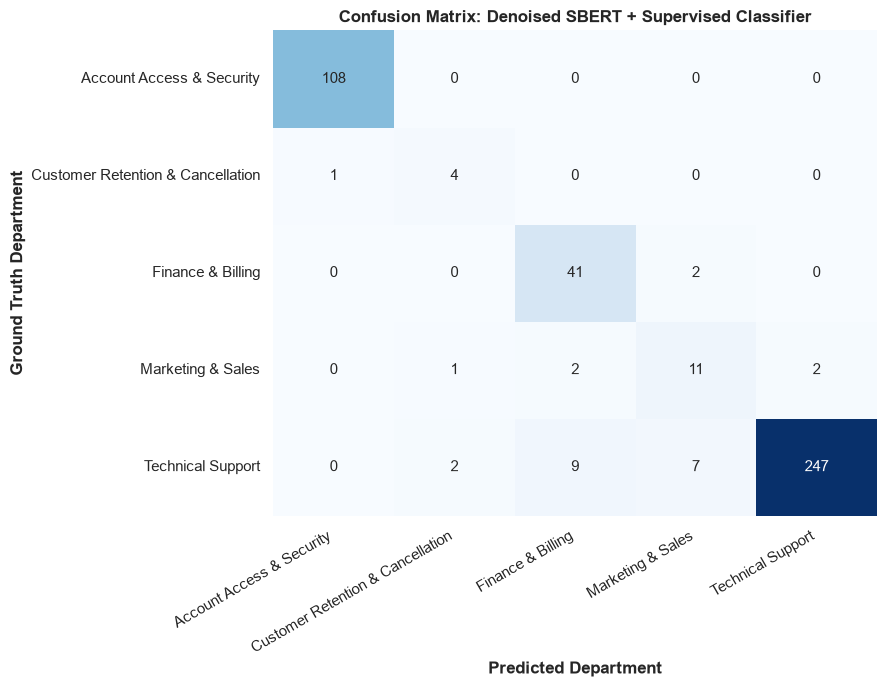

In [5]:
print("=" * 70)
print("            DENOISED MODEL CLASSIFICATION REPORT")
print("=" * 70)
print(classification_report(y_test, y_pred, digits=4))

labels = sorted(list(clf.classes_))
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, cbar=False)
plt.title("Confusion Matrix: Denoised SBERT + Supervised Classifier", weight="bold")
plt.xlabel("Predicted Department", weight="bold")
plt.ylabel("Ground Truth Department", weight="bold")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

---

### Validation on Unseen Real-World Test Cases

In [6]:
unseen_complaints = [
    "I was charged twice on my credit card invoice. Please refund the extra money.",
    "The screen went completely black and the device refuses to turn on.",
    "I forgot my password and my 2FA authentication code is not sending. Unlock my account.",
    "I want to cancel our enterprise membership and terminate our subscription immediately.",
    "Could you provide pricing details and tell me if this accessory is compatible with my Mac?"
]

print("--- TESTING GENERALIZATION ON REAL UNSEEN COMPLAINTS ---")
test_vecs = embedder.encode(unseen_complaints, normalize_embeddings=True)
test_preds = clf.predict(test_vecs)
test_probs = clf.predict_proba(test_vecs)

for text, pred, probs in zip(unseen_complaints, test_preds, test_probs):
    print(f"\nComplaint: \"{text}\"")
    print(f"-> Predicted: {pred} ({np.max(probs) * 100:.1f}%)")

--- TESTING GENERALIZATION ON REAL UNSEEN COMPLAINTS ---

Complaint: "I was charged twice on my credit card invoice. Please refund the extra money."
-> Predicted: Finance & Billing (99.8%)

Complaint: "The screen went completely black and the device refuses to turn on."
-> Predicted: Technical Support (76.6%)

Complaint: "I forgot my password and my 2FA authentication code is not sending. Unlock my account."
-> Predicted: Account Access & Security (96.7%)

Complaint: "I want to cancel our enterprise membership and terminate our subscription immediately."
-> Predicted: Customer Retention & Cancellation (99.2%)

Complaint: "Could you provide pricing details and tell me if this accessory is compatible with my Mac?"
-> Predicted: Marketing & Sales (97.9%)


---

### Export Serialized Artifacts

In [8]:
model_path = os.path.join(MODEL_DIR, "dense_ticket_classifier.joblib")

joblib.dump({
    "classifier": clf,
    "classes": clf.classes_.tolist(),
    "model_name": "all-MiniLM-L6-v2"
}, model_path)

print(f"Successfully saved production model to: {model_path}")

Successfully saved production model to: ../model_output/dense_ticket_classifier.joblib
